# 02 End-to-End Training Demo

This notebook performs one pretrained NeuPSL fine-tuning run. Every 10 NeuPSL gradient steps it saves a Transformer checkpoint that can be used for resume. At the final step it shows the trained Transformer output, DeepPredicate digit atoms, and the fused `ImageSum` soft vector.

In [10]:
from collections import defaultdict
from pathlib import Path
import importlib
import shutil
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from models.transformer import load_checkpoint
import psl.runner as psl_runner_module
from scripts.check_env import check_environment
from utils.config import DatasetConfig, inference_dir, neupsl_train_dir, result_dir as build_result_dir
from utils.io import load_json, load_psl, write_json

psl_runner_module = importlib.reload(psl_runner_module)
PSLRunner = psl_runner_module.PSLRunner

check_environment()

{'python': '/Users/zmx/.pyenv/versions/.neupsl_env/bin/python',
 'python_version': '3.10.0',
 'java_ok': True,
 'java_path': '/usr/bin/java',
 'java_version': 'openjdk version "11.0.23" 2024-04-16 LTS',
 'pslpython_ok': True,
 'pslpython_runtime_ok': True,
 'pslpython_version': 'unknown',
 'pslpython_error': '',
 'ready': True}

## Generate Real-MNIST Training Data

The data generator writes separate PSL-compatible pretraining, NeuPSL training/validation, and inference directories. The training run below uses the NeuPSL training predicates and validation predicates from the prepared data.

In [11]:
config = DatasetConfig(
    name="mnist-1",
    pretrain_size=500,
    pretrain_valid_size=100,
    pretrain_overlap=0.4,
    train_size=50,
    valid_size=100,
    inference_size=1000,
    overlap=0.0,
)
train_data_dir = neupsl_train_dir(config)
inference_data_dir = inference_dir(config)
if not (train_data_dir / "entity-data-map.txt").exists():
    raise FileNotFoundError(
        f"Missing prepared NeuPSL training data: {train_data_dir}. "
        "Run scripts/create_data.py before opening this notebook."
    )
if not (inference_data_dir / "entity-data-map.txt").exists():
    raise FileNotFoundError(
        f"Missing prepared inference data: {inference_data_dir}. "
        "Run scripts/create_data.py before opening this notebook."
    )

result_dir = build_result_dir(config)
result_dir.mkdir(parents=True, exist_ok=True)
checkpoint_dir = result_dir / "checkpoints"

train_data_dir, inference_data_dir, result_dir, checkpoint_dir


(PosixPath('/Users/zmx/Desktop/neupsl-intent/data/experiment_mnist-1/neupsl-train/size_0050-valid_0100-overlap_0.00'),
 PosixPath('/Users/zmx/Desktop/neupsl-intent/data/experiment_mnist-1/inference/size_1000'),
 PosixPath('/Users/zmx/Desktop/neupsl-intent/results/train_50_infer_1000'),
 PosixPath('/Users/zmx/Desktop/neupsl-intent/results/train_50_infer_1000/checkpoints'))

## Helpers

In [12]:
def round_probs(values, digits=4):
    return [round(float(value), digits) for value in values]


def argmax_label(values):
    return int(np.argmax(np.asarray(values, dtype=float)))


def collect_atoms(payload):
    neural = defaultdict(dict)
    image_sum = defaultdict(dict)
    for atom in payload.get("atoms", []):
        predicate = atom["predicate"]
        args = [int(value) for value in atom["arguments"]]
        if predicate == "NEURALCLASSIFIER":
            image_id, digit = args
            neural[image_id][digit] = float(atom["value"])
        elif predicate == "IMAGESUM":
            image_1, image_2, sum_value = args
            image_sum[(image_1, image_2)][sum_value] = float(atom["value"])
    return neural, image_sum


def entity_lookup(path):
    rows = load_psl(path, dtype=float)
    return {int(row[0]): (np.asarray(row[1:-1], dtype=np.float32), int(row[-1])) for row in rows}


def true_sum_lookup(path):
    truth = {}
    for row in load_psl(path, dtype=int):
        image_1, image_2, sum_value, is_true = row
        if is_true == 1:
            truth[(image_1, image_2)] = sum_value
    return truth


def model_digit_accuracy(model, lookup):
    image_ids = sorted(lookup)
    features = np.stack([lookup[image_id][0] for image_id in image_ids])
    labels = np.asarray([lookup[image_id][1] for image_id in image_ids])
    preds = np.argmax(model.predict(features), axis=1)
    return float(np.mean(preds == labels))


def digit_report(image_id, model, neural_atoms):
    image_features, true_digit = inference_entities[image_id]
    cnn_probs = model.predict(image_features.reshape(1, -1))[0]
    psl_probs = [neural_atoms[image_id].get(digit, 0.0) for digit in range(config.class_size)]
    return {
        "image_id": image_id,
        "true_digit": true_digit,
        "features": image_features,
        "cnn_probs": cnn_probs.tolist(),
        "cnn_pred": argmax_label(cnn_probs),
        "psl_probs": psl_probs,
        "psl_pred": argmax_label(psl_probs),
    }


train_entities = entity_lookup(train_data_dir / "entity-data-map.txt")
inference_entities = entity_lookup(inference_data_dir / "entity-data-map.txt")
true_sums = true_sum_lookup(inference_data_dir / "image-sum-truth-inference.txt")

## Run One Pretrained NeuPSL Fine-Tuning Job

This is the only NeuPSL run in this notebook. It initializes the Transformer from the supervised pretraining checkpoint, then updates it with PSL gradients during weight learning while PSL rule weights are learned by the runtime.

In [13]:
runner = PSLRunner()
final_save_dir = result_dir / "saved-networks" / "nesy-trained-pt"
pretrained_path = PROJECT_ROOT / "ckpt" / "pretrained-transformer.pt"
if not pretrained_path.exists():
    raise FileNotFoundError(
        f"Missing pretrained checkpoint: {pretrained_path}. "
        "Run scripts/pretrain_transformer.py first, or pass a custom checkpoint path."
    )

config_path = runner.build_config(
    config,
    output_path=result_dir / "psl-config.json",
    learning_rate=2e-5,
    batch_size=128,
    gradient_steps=50,
    admm_iterations=50,
    checkpoint_dir=checkpoint_dir,
    checkpoint_frequency=10,
    log_level="INFO",
    random_seed=16,
    save_path=final_save_dir,
    pretrained_path=pretrained_path,
)
psl_config = load_json(config_path)
psl_config["options"]["gradientdescent.stepsize"] = 1e-8
write_json(config_path, psl_config, indent=2)


payload = runner.run_runtime(config_path, result_dir)
model_path = final_save_dir / "model.pt"
exported_model_path = result_dir / "model.pt"
if model_path.exists():
    shutil.copy2(model_path, exported_model_path)
learned_rules_path = result_dir / "learned-rules.txt"

print("runtime output:", result_dir / "runtime-output.json")
print("pretrained Transformer:", pretrained_path)
print("trained Transformer:", exported_model_path)
print("learned PSL rules:", learned_rules_path)
print("checkpoints:", checkpoint_dir)
print("evaluations:", payload.get("evaluations", []))

94052 [main] INFO  org.linqs.psl.runtime.Runtime  - PSL Runtime Version 2.4.0-aad67da
94111 [main] INFO  org.linqs.psl.application.inference.InferenceApplication  - Grounding out model.
94166 [main] INFO  org.linqs.psl.application.inference.InferenceApplication  - Grounding complete.
94166 [main] INFO  org.linqs.psl.application.inference.InferenceApplication  - Loading deep predicates.
96273 [main] INFO  org.linqs.psl.application.inference.InferenceApplication  - Grounding out model.
96276 [main] INFO  org.linqs.psl.application.inference.InferenceApplication  - Grounding complete.
96300 [main] INFO  org.linqs.psl.application.learning.weight.gradient.GradientDescent  - Gradient Descent Weight Learning Start.
96499 [main] INFO  org.linqs.psl.application.inference.InferenceApplication  - Beginning inference.
96511 [main] INFO  org.linqs.psl.reasoner.Reasoner  - Final Objective: 1.603611, Violated Constraints: 0, Total Optimization Time: 11, Total Number of Iterations: 19
96511 [main] INFO

Traceback (most recent call last):
  File "/Users/zmx/.pyenv/versions/3.10.0/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/zmx/.pyenv/versions/3.10.0/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/zmx/.pyenv/versions/.neupsl_env/lib/python3.10/site-packages/pslpython/deeppsl/server.py", line 228, in <module>
    main(_load_args(list(sys.argv)))
  File "/Users/zmx/.pyenv/versions/.neupsl_env/lib/python3.10/site-packages/pslpython/deeppsl/server.py", line 210, in main
    sock.shutdown(socket.SHUT_RDWR)
OSError: [Errno 57] Socket is not connected


144475 [main] INFO  org.linqs.psl.application.inference.InferenceApplication  - Writing results to Database.
144508 [main] INFO  org.linqs.psl.application.inference.InferenceApplication  - Results committed to database.
144508 [main] INFO  org.linqs.psl.application.inference.InferenceApplication  - Writing results to Database.
144508 [main] INFO  org.linqs.psl.application.inference.InferenceApplication  - Results committed to database.
144521 [main] INFO  org.linqs.psl.runtime.Runtime  - Learned Model:
144521 [main] INFO  org.linqs.psl.runtime.Runtime  -    0.19607843: ( NUMBERSUM(X, Y, Z) & NEURALCLASSIFIER(ImageId2, Y) & NEURALCLASSIFIER(ImageId1, X) & IMAGESUMBLOCK(ImageId1, ImageId2) ) >> IMAGESUM(ImageId1, ImageId2, Z) ^2
144521 [main] INFO  org.linqs.psl.runtime.Runtime  -    0.19607843: ( IMAGESUM(ImageId1, ImageId2, Z) & NUMBERSUM(X, Y, Z) & NEURALCLASSIFIER(ImageId1, X) & IMAGESUMBLOCK(ImageId1, ImageId2) ) >> NEURALCLASSIFIER(ImageId2, Y) ^2
144521 [main] INFO  org.linqs.psl.

Traceback (most recent call last):
  File "/Users/zmx/.pyenv/versions/3.10.0/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/zmx/.pyenv/versions/3.10.0/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/zmx/.pyenv/versions/.neupsl_env/lib/python3.10/site-packages/pslpython/deeppsl/server.py", line 228, in <module>
    main(_load_args(list(sys.argv)))
  File "/Users/zmx/.pyenv/versions/.neupsl_env/lib/python3.10/site-packages/pslpython/deeppsl/server.py", line 210, in main
    sock.shutdown(socket.SHUT_RDWR)
OSError: [Errno 57] Socket is not connected


runtime output: /Users/zmx/Desktop/neupsl-intent/results/train_50_infer_1000/runtime-output.json
pretrained Transformer: /Users/zmx/Desktop/neupsl-intent/ckpt/pretrained-transformer.pt
trained Transformer: /Users/zmx/Desktop/neupsl-intent/results/train_50_infer_1000/model.pt
learned PSL rules: /Users/zmx/Desktop/neupsl-intent/results/train_50_infer_1000/learned-rules.txt
checkpoints: /Users/zmx/Desktop/neupsl-intent/results/train_50_infer_1000/checkpoints
evaluations: ['Evaluator: CategoricalEvaluator, Predicate: IMAGESUM, Results -- Categorical Accuracy: 0.032000']


## Step Checkpoints

These checkpoint files are saved by the NeuPSL DeepModel every 10 gradient steps. If the notebook or script is run again with the same result directory, learning resumes from the latest checkpoint.

In [14]:
checkpoint_rows = []
for path in sorted(checkpoint_dir.glob("step_*.pt")):
    step = int(path.stem.rsplit("_", 1)[-1])
    checkpoint_model = load_checkpoint(path)
    checkpoint_rows.append({
        "step": step,
        "path": path,
        "train_digit_accuracy": model_digit_accuracy(checkpoint_model, train_entities),
    })

for row in checkpoint_rows:
    print(f"step={row['step']:04d} train_digit_accuracy={row['train_digit_accuracy']:.4f} checkpoint={row['path'].name}")

step=0010 train_digit_accuracy=0.2000 checkpoint=step_0010.pt
step=0020 train_digit_accuracy=0.2200 checkpoint=step_0020.pt
step=0030 train_digit_accuracy=0.2133 checkpoint=step_0030.pt
step=0040 train_digit_accuracy=0.2000 checkpoint=step_0040.pt
step=0050 train_digit_accuracy=0.1733 checkpoint=step_0050.pt


## Final Transformer Output and PSL-Fused System Output

After training finishes, the runtime returns final atoms. Here we show one addition pair with trained-Transformer vectors, DeepPredicate digit atoms, and the fused sum soft vector.

In [15]:
model = load_checkpoint(exported_model_path)
final_neural_atoms, final_image_sum_atoms = collect_atoms(payload)
display_pair = sorted(final_image_sum_atoms.keys())[0]
d1 = digit_report(display_pair[0], model, final_neural_atoms)
d2 = digit_report(display_pair[1], model, final_neural_atoms)
sum_probs = [final_image_sum_atoms[display_pair].get(sum_value, 0.0) for sum_value in range(config.max_sum + 1)]
sum_pred = argmax_label(sum_probs)
true_sum = true_sums[display_pair]
print(f"任务: image {d1['image_id']} + image {d2['image_id']}，真实数字 {d1['true_digit']} + {d2['true_digit']} = {true_sum}")
print(f"Transformer输出1: {round_probs(d1['cnn_probs'])} -> 预测数字 {d1['cnn_pred']}")
print(f"Transformer输出2: {round_probs(d2['cnn_probs'])} -> 预测数字 {d2['cnn_pred']}")
print(f"Transformer预测相加: {d1['cnn_pred']} + {d2['cnn_pred']} = {d1['cnn_pred'] + d2['cnn_pred']}")
print(f"DeepPredicate数字原子1: {round_probs(d1['psl_probs'])} -> 预测数字 {d1['psl_pred']}")
print(f"DeepPredicate数字原子2: {round_probs(d2['psl_probs'])} -> 预测数字 {d2['psl_pred']}")
print(f"PSL数字预测相加: {d1['psl_pred']} + {d2['psl_pred']} = {d1['psl_pred'] + d2['psl_pred']}")
print(f"PSL融合后加法软标签: {round_probs(sum_probs)} -> 预测和 {sum_pred}")

任务: image 18 + image 18593，真实数字 6 + 6 = 12
Transformer输出1: [0.0445, 0.2232, 0.0839, 0.0663, 0.1011, 0.0935, 0.1016, 0.1253, 0.083, 0.0776] -> 预测数字 1
Transformer输出2: [0.1239, 0.0514, 0.125, 0.1125, 0.0645, 0.0753, 0.118, 0.1091, 0.1521, 0.0681] -> 预测数字 8
Transformer预测相加: 1 + 8 = 9
DeepPredicate数字原子1: [0.0445, 0.2232, 0.0839, 0.0663, 0.1011, 0.0935, 0.1016, 0.1253, 0.083, 0.0776] -> 预测数字 1
DeepPredicate数字原子2: [0.1239, 0.0514, 0.125, 0.1125, 0.0645, 0.0753, 0.118, 0.1091, 0.1521, 0.0681] -> 预测数字 8
PSL数字预测相加: 1 + 8 = 9
PSL融合后加法软标签: [0.0087, 0.0058, 0.0043, 0.0035, 0.0029, 0.0025, 0.0022, 0.0019, 0.0017, 0.0016, 0.0017, 0.0019, 0.0022, 0.0025, 0.0029, 0.0035, 0.0043, 0.0058, 0.0087] -> 预测和 0


## Training Curves and Saved Artifacts

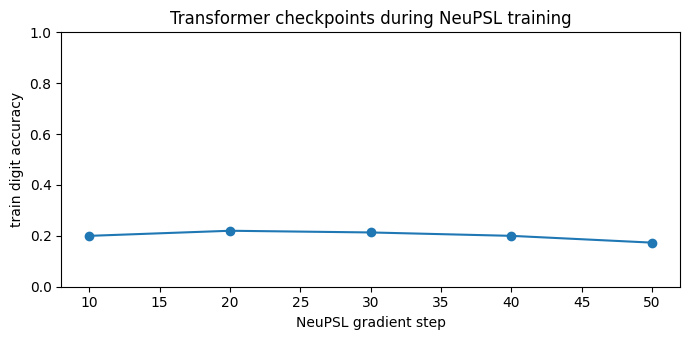

In [16]:
if checkpoint_rows:
    steps = [row["step"] for row in checkpoint_rows]
    acc = [row["train_digit_accuracy"] for row in checkpoint_rows]
    plt.figure(figsize=(7, 3.5))
    plt.plot(steps, acc, marker="o")
    plt.xlabel("NeuPSL gradient step")
    plt.ylabel("train digit accuracy")
    plt.title("Transformer checkpoints during NeuPSL training")
    plt.ylim(0, 1)
    plt.tight_layout()
else:
    print("No step checkpoints found.")

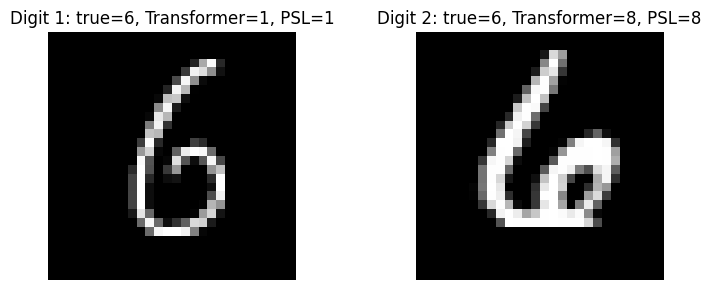

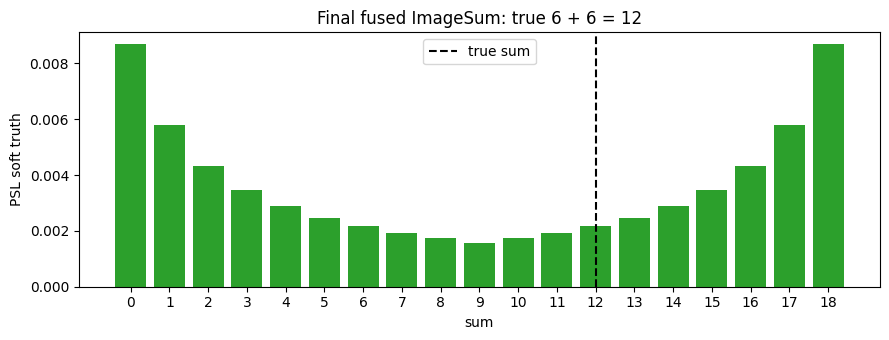

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, digit_row, title in zip(axes, [d1, d2], ["Digit 1", "Digit 2"]):
    ax.imshow(digit_row["features"].reshape(28, 28), cmap="gray")
    ax.set_title(f"{title}: true={digit_row['true_digit']}, Transformer={digit_row['cnn_pred']}, PSL={digit_row['psl_pred']}")
    ax.axis("off")
plt.tight_layout()

sum_values = np.arange(config.max_sum + 1)
plt.figure(figsize=(9, 3.5))
plt.bar(sum_values, sum_probs, color="tab:green")
plt.axvline(true_sum, color="black", linestyle="--", label="true sum")
plt.xticks(sum_values)
plt.xlabel("sum")
plt.ylabel("PSL soft truth")
plt.title(f"Final fused ImageSum: true {d1['true_digit']} + {d2['true_digit']} = {true_sum}")
plt.legend()
plt.tight_layout()

In [18]:
print("Transformer checkpoint exists:", exported_model_path.exists(), exported_model_path)
print("runtime output exists:", (result_dir / "runtime-output.json").exists(), result_dir / "runtime-output.json")
print("learned rules JSON exists:", (result_dir / "learned-rules.json").exists(), result_dir / "learned-rules.json")
print("learned rules TXT exists:", learned_rules_path.exists(), learned_rules_path)

print("\nLearned PSL rules excerpt:")
for rule in payload.get("rules", [])[:5]:
    print("-", rule)

Transformer checkpoint exists: True /Users/zmx/Desktop/neupsl-intent/results/train_50_infer_1000/model.pt
runtime output exists: True /Users/zmx/Desktop/neupsl-intent/results/train_50_infer_1000/runtime-output.json
learned rules JSON exists: True /Users/zmx/Desktop/neupsl-intent/results/train_50_infer_1000/learned-rules.json
learned rules TXT exists: True /Users/zmx/Desktop/neupsl-intent/results/train_50_infer_1000/learned-rules.txt

Learned PSL rules excerpt:
- {'text': '1.0: ( NUMBERSUM(X, Y, Z) & NEURALCLASSIFIER(ImageId2, Y) & NEURALCLASSIFIER(ImageId1, X) & IMAGESUMBLOCK(ImageId1, ImageId2) ) >> IMAGESUM(ImageId1, ImageId2, Z) ^2', 'weight': 1.0, 'squared': True, 'ruleIndex': 0}
- {'text': '1.0: ( IMAGESUM(ImageId1, ImageId2, Z) & NUMBERSUM(X, Y, Z) & NEURALCLASSIFIER(ImageId1, X) & IMAGESUMBLOCK(ImageId1, ImageId2) ) >> NEURALCLASSIFIER(ImageId2, Y) ^2', 'weight': 1.0, 'squared': True, 'ruleIndex': 1}
- {'text': '1.0: ( IMAGESUM(ImageId1, ImageId2, Z) & NUMBERSUM(X, Y, Z) & NEURA